In [1]:
import sys

sys.path.append("..")

import matplotlib.pyplot as plt
import numpy as np

In [2]:
from candidate.candidate import Candidate
from voter.voter import Voter
from election.election import Election
from election.result import ElectionResult
from analysis.analyzer import ResultsAnalyzer

from strategy.strategy import VotingStrategy
from strategy.plurality import PluralityStrategy
from strategy.borda import BordaCountStrategy
from strategy.veto import VetoStrategy

from visualization.util import (
    plot,
    plot_results,
    random_2d_points,
    random_2d_point,
    plot_winner_distance_histogram,
)

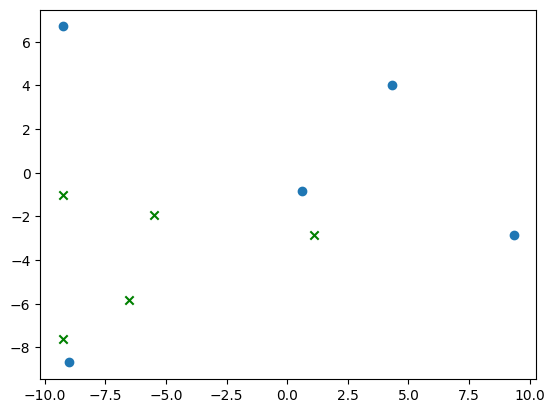

In [3]:
plot(random_2d_points(), random_2d_points())

In [4]:
candidates = [Candidate(id=id, position=random_2d_point()) for id in range(5)]
voters = [Voter(position=random_2d_point()) for _ in range(15)]
election = Election(candidates=candidates, voters=voters)

In [5]:
strategies = [PluralityStrategy(), BordaCountStrategy(), VetoStrategy()]
election_result = election.compare_strategies(strategies=strategies)

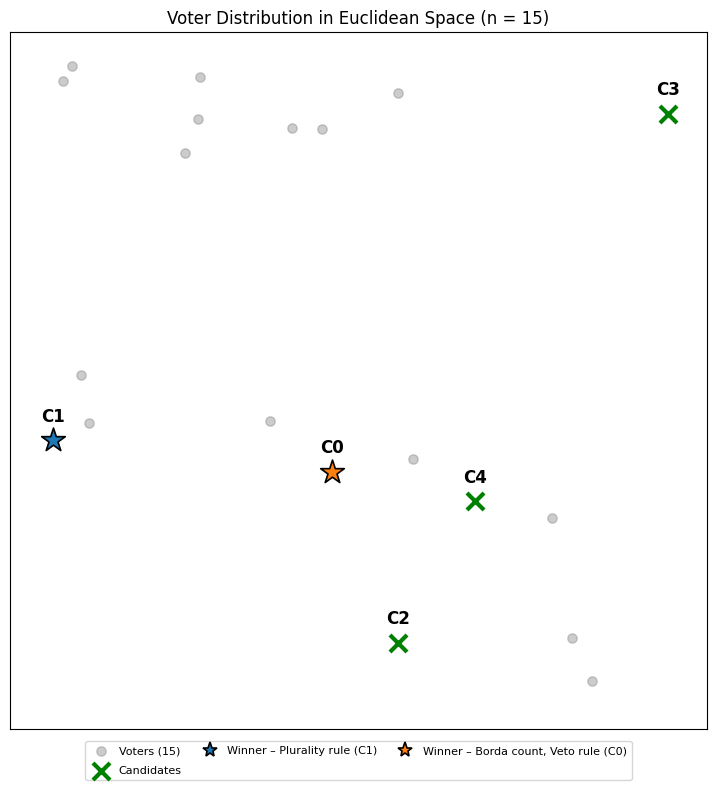

In [6]:
plot_results(election_result)

In [7]:
import random


def cluster_point(centers, std=0.7, weights=None):
    center = random.choices(centers, weights=weights)[0]
    return (random.gauss(center[0], std), random.gauss(center[1], std))

In [8]:
strategies = [PluralityStrategy(), BordaCountStrategy(), VetoStrategy()]
election_results: list[ElectionResult] = []

# candidates = [Candidate(id=id, position=random_2d_point()) for id in range(10)]

N = 1000
n_tied = 0
for _ in range(N):
    candidates = [Candidate(id=id, position=random_2d_point()) for id in range(50)]
    voters = [Voter(position=random_2d_point()) for _ in range(100)]
    # voters = [Voter(position=cluster_point([(-2, 2), (2, 2)])) for _ in range(100)]
    # voters = [Voter(position=cluster_point([(-2, -2), (2, -2), (-2, 2), (2, 2)])) for _ in range(100)]
    election = Election(candidates=candidates, voters=voters)

    election_result = election.compare_strategies(strategies=strategies)
    if any(t.is_tie() for t in election_result.tallies.values()):
        n_tied += 1
    election_results.append(election_result)

print(f"tied elections: {n_tied}/{N} ({n_tied / N:.1%})")

KeyboardInterrupt: 

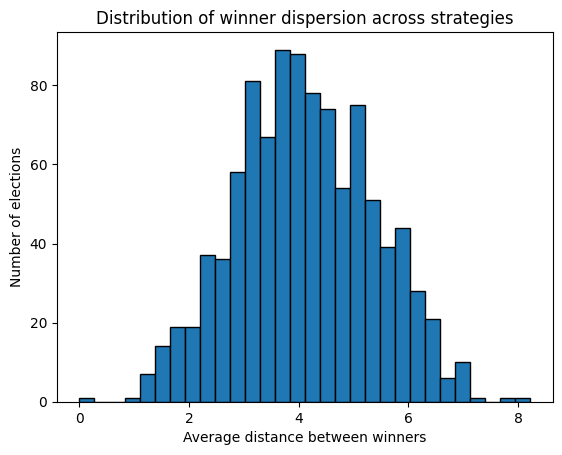

In [ ]:
analyzer = ResultsAnalyzer(election_results)
distances = analyzer.winner_distance_series()

plot_winner_distance_histogram(distances=distances, bins=30)

In [ ]:
max_el_idx = np.argmax(distances)
min_el_idx = np.argmin(distances)

max_el, min_el = election_results[max_el_idx], election_results[min_el_idx]

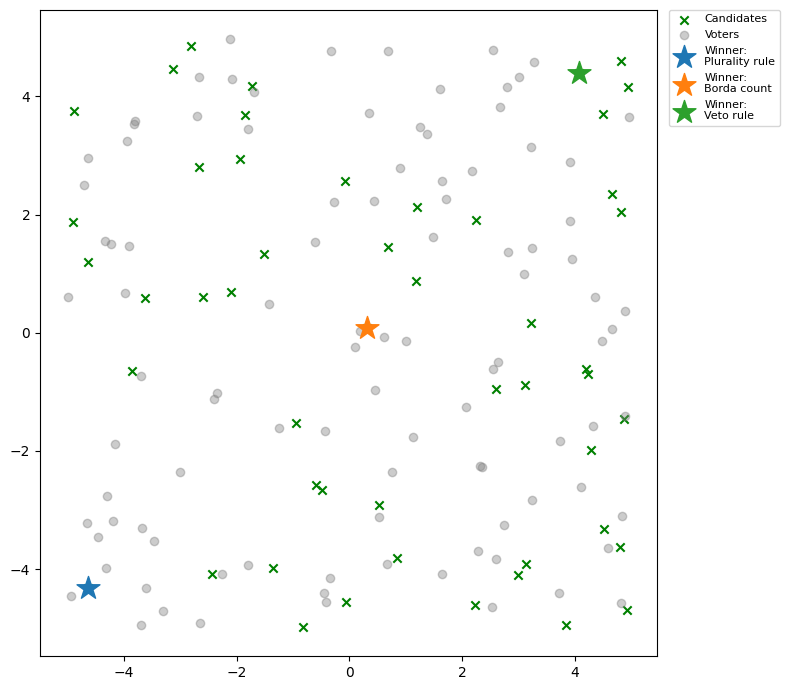

In [ ]:
plot_results(max_el)

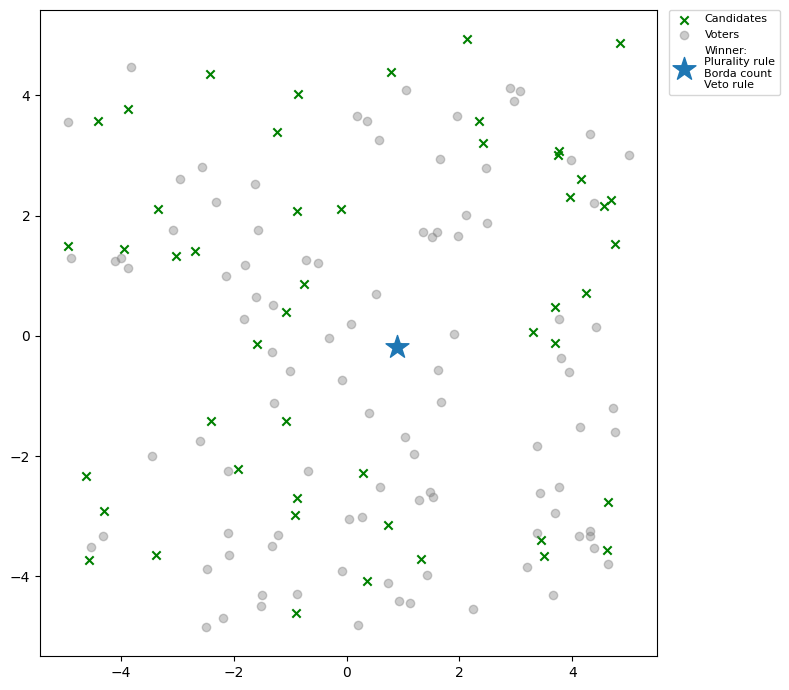

In [ ]:
plot_results(min_el)

## Nested Monte Carlo: random candidates AND random voters

Outer loop draws candidate configurations; inner loop draws voter samples per config.
This separates *within-config* variance (sensitivity to the voter draw) from *across-config* variance (sensitivity to where candidates sit).

`ElectionResult` and `ResultsAnalyzer` are reused unchanged — the analyzer is just instantiated per group for within-config stats, and once over the flat list for overall stats.

In [ ]:
N_CONFIGS = 200
N_VOTER_SAMPLES = 20
N_CANDIDATES = 5
N_VOTERS = 100

nested_results: list[list[ElectionResult]] = []
n_total = 0
n_tied = 0

for _ in range(N_CONFIGS):
    candidates = [
        Candidate(id=id, position=random_2d_point()) for id in range(N_CANDIDATES)
    ]

    group: list[ElectionResult] = []
    for _ in range(N_VOTER_SAMPLES):
        voters = [Voter(position=random_2d_point()) for _ in range(N_VOTERS)]
        election = Election(candidates=candidates, voters=voters)
        result = election.compare_strategies(strategies=strategies)
        n_total += 1
        if any(t.is_tie() for t in result.tallies.values()):
            n_tied += 1
        group.append(result)

    nested_results.append(group)

print(f"tied elections: {n_tied}/{n_total} ({n_tied / n_total:.1%})")

tied elections: 2029/4000 (50.7%)


In [ ]:
# Within-config: mean winner-distance per candidate configuration
# (averaged across that config's voter samples)
per_config_mean_distance = []
per_config_std_distance = []

for group in nested_results:
    distances = ResultsAnalyzer(group).winner_distance_series()
    per_config_mean_distance.append(float(np.mean(distances)))
    per_config_std_distance.append(float(np.std(distances)))

# Across-config: pooled distribution over every draw
flat_results = [r for group in nested_results for r in group]
flat_distances = ResultsAnalyzer(flat_results).winner_distance_series()

print(f"Overall mean winner-distance:        {np.mean(flat_distances):.3f}")
print(f"Std across all draws (pooled):       {np.std(flat_distances):.3f}")
print(f"Std of per-config means (between):   {np.std(per_config_mean_distance):.3f}")
print(f"Mean of per-config stds (within):    {np.mean(per_config_std_distance):.3f}")

Overall mean winner-distance:        2.592
Std across all draws (pooled):       1.710
Std of per-config means (between):   1.260
Mean of per-config stds (within):    0.921


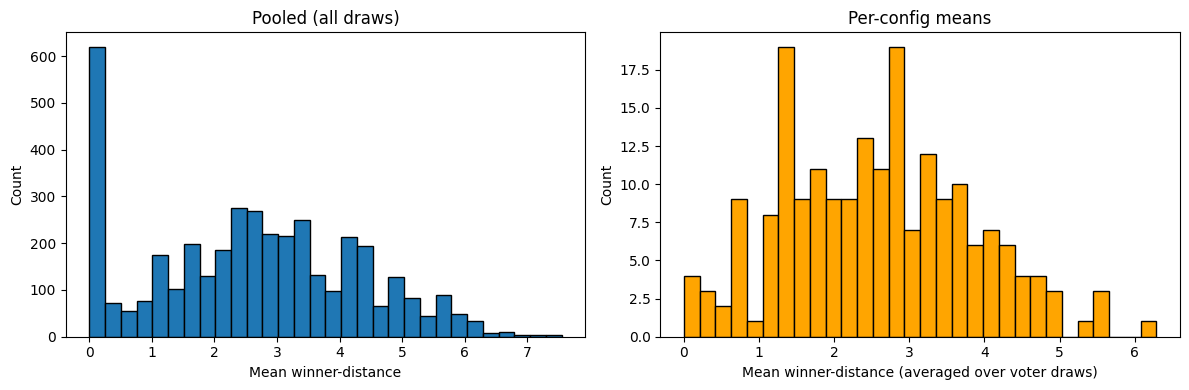

In [ ]:
# Side-by-side: pooled distribution vs. distribution of per-config means
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(flat_distances, bins=30, edgecolor="black")
axes[0].set_title("Pooled (all draws)")
axes[0].set_xlabel("Mean winner-distance")
axes[0].set_ylabel("Count")

axes[1].hist(per_config_mean_distance, bins=30, edgecolor="black", color="orange")
axes[1].set_title("Per-config means")
axes[1].set_xlabel("Mean winner-distance (averaged over voter draws)")
axes[1].set_ylabel("Count")

plt.tight_layout()
plt.show()

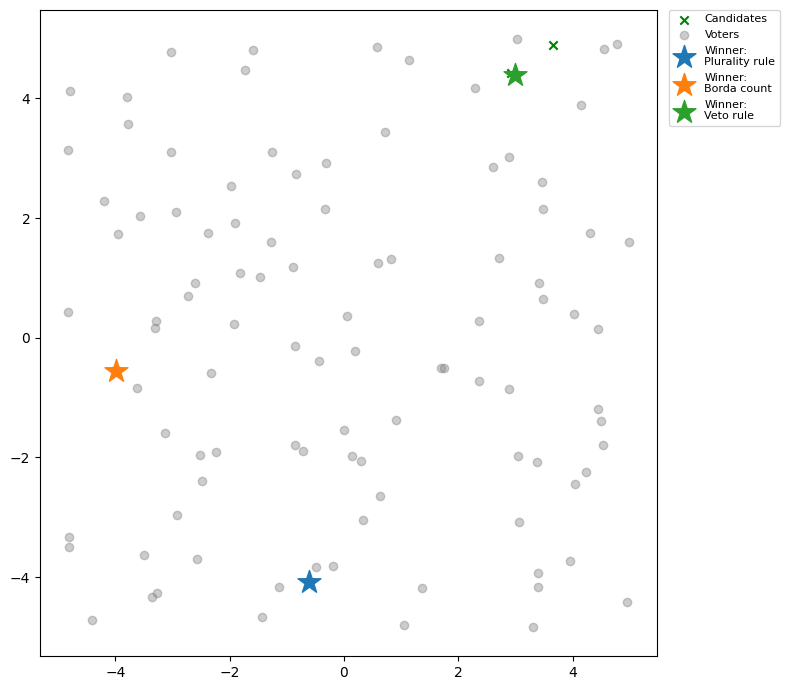

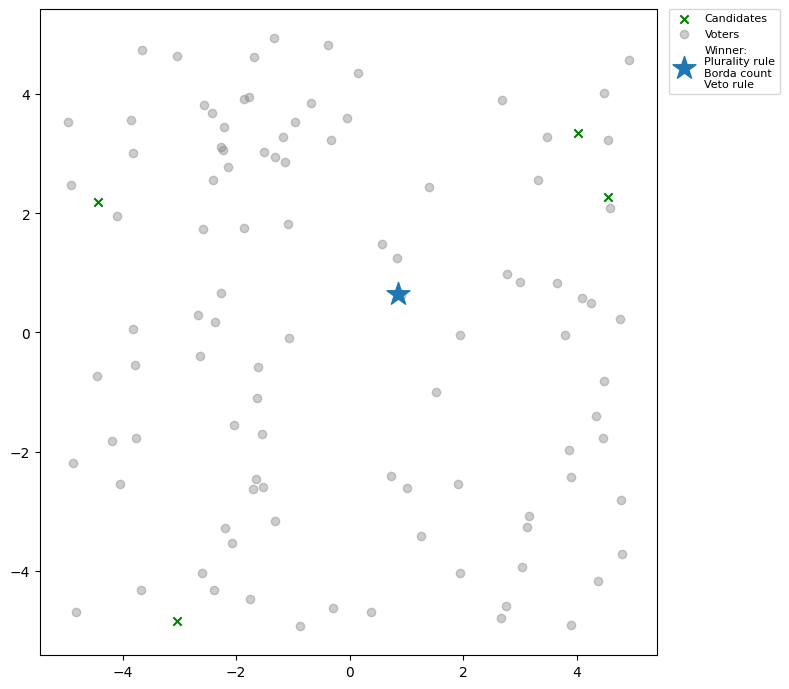

In [ ]:
# Most/least disagreeing candidate configurations (by mean winner-distance)
worst_config_idx = int(np.argmax(per_config_mean_distance))
best_config_idx = int(np.argmin(per_config_mean_distance))

# Within each, pick the single election that exemplifies the config's tendency
worst_group = nested_results[worst_config_idx]
best_group = nested_results[best_config_idx]

worst_group_distances = ResultsAnalyzer(worst_group).winner_distance_series()
best_group_distances = ResultsAnalyzer(best_group).winner_distance_series()

plot_results(worst_group[int(np.argmax(worst_group_distances))])
plot_results(best_group[int(np.argmin(best_group_distances))])